<a href="https://colab.research.google.com/github/Frank-Aniekeme/TS-ACADEMY-DATA-SCIENCE-CAPSTONE-PROJECT/blob/main/TS_Academy_Capstone_Project_Stroke_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## My TS Academy Data Science Capstone Project
## Stroke Prediction Dataset

**Dataset:** Stroke Prediction Dataset (Kaggle: `fedesoriano/stroke-prediction-dataset`)
**Author:** Aniekeme Frank

**Part 1 Workflow:**

1. Load the raw CSV from Kaggle and push it into a SQLite database
2. Run SQL queries against that database to surface early patterns
3. Perform exploratory data analysis (EDA)
4. Clean the data — every step justified, no blanket `fillna()`, no unexplained row drops


## 1. Load the Dataset from Kaggle and Push it into SQLite

In [3]:
# Install the Kaggle API client (Colab usually has it pre-installed, but this pins it)
!pip install -q kaggle

In [5]:
# Upload your kaggle.json API token
# Get this from kaggle.com -> Account -> Settings -> API -> "Create New Token"
from google.colab import files
uploaded = files.upload()  # select kaggle.json when the file picker opens

Saving healthcare-dataset-stroke-data.csv to healthcare-dataset-stroke-data.csv


In [ ]:
# Put the credentials where the Kaggle CLI expects them, and lock down permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset directly from Kaggle and unzip it into /content
!kaggle datasets download -d fedesoriano/stroke-prediction-dataset -p /content --unzip

In [7]:
import pandas as pd

# Load the raw CSV Kaggle just downloaded
df = pd.read_csv('/content/healthcare-dataset-stroke-data.csv')
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [8]:
df.tail(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5100,68398,Male,82.0,1,0,Yes,Self-employed,Rural,71.97,28.3,never smoked,0
5101,36901,Female,45.0,0,0,Yes,Private,Urban,97.95,24.5,Unknown,0
5102,45010,Female,57.0,0,0,Yes,Private,Rural,77.93,21.7,never smoked,0
5103,22127,Female,18.0,0,0,No,Private,Urban,82.85,46.9,Unknown,0
5104,14180,Female,13.0,0,0,No,children,Rural,103.08,18.6,Unknown,0
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [9]:
import sqlite3

# Create (or connect to) a SQLite database file on the Colab filesystem
conn = sqlite3.connect('stroke_data.db')

# Push the *raw, unmodified* dataframe into a table called 'patients'.
# We push the raw data first (before any cleaning) so the SQL queries in
# Section 2 reflect the dataset exactly as it arrived — cleaning happens
df.to_sql('patients', conn, if_exists='replace', index=False)

# Sanity check: row count in the database should match the dataframe
pd.read_sql("SELECT COUNT(*) AS row_count FROM patients;", conn)

,row_count
0,5110


**Check:** the query above should return `5110` — matching `df.shape[0]`. This confirms every
row made it into the database and nothing was silently dropped during the load.

## 2. SQL Queries — What the Raw Data Already Tells Us

Before touching pandas for EDA, i am going to be interrogating the data directly in SQL, this  forces
simple, well-defined questions and is fast to iterate on. Four queries below (more than the
minimum of three) each surface a different angle on stroke risk.

### Query 1 — Stroke rate by age band

In [10]:
query1 = """
SELECT
    CASE
        WHEN age < 18 THEN '0-17'
        WHEN age < 40 THEN '18-39'
        WHEN age < 60 THEN '40-59'
        WHEN age < 80 THEN '60-79'
        ELSE '80+'
    END AS age_band,
    COUNT(*) AS total_patients,
    SUM(stroke) AS stroke_cases,
    ROUND(100.0 * SUM(stroke) / COUNT(*), 2) AS stroke_rate_pct
FROM patients
GROUP BY age_band
ORDER BY MIN(age);
"""
pd.read_sql(query1, conn)

,age_band,total_patients,stroke_cases,stroke_rate_pct
0,0-17,856,2,0.23
1,18-39,1314,6,0.46
2,40-59,1564,60,3.84
3,60-79,1190,141,11.85
4,80+,186,40,21.51


**What I learned:** stroke risk is overwhelmingly an age story. The rate climbs from
essentially zero in patients under 18 (0.23%) to 3.84% in the 40-59 band, 11.85% in the 60-79
band, and 21.51% in patients 80 and older,  a roughly 90x increase from the youngest to the
oldest band. This confirms age will likely be the single strongest predictor available.

### Query 2 — Stroke rate by hypertension and heart disease

In [11]:
query2 = """
SELECT
    hypertension,
    heart_disease,
    COUNT(*) AS total_patients,
    SUM(stroke) AS stroke_cases,
    ROUND(100.0 * SUM(stroke) / COUNT(*), 2) AS stroke_rate_pct
FROM patients
GROUP BY hypertension, heart_disease
ORDER BY stroke_rate_pct DESC;
"""
pd.read_sql(query2, conn)

,hypertension,heart_disease,total_patients,stroke_cases,stroke_rate_pct
0,1,1,64,13,20.31
1,0,1,212,34,16.04
2,1,0,434,53,12.21
3,0,0,4400,149,3.39


**What I learned:** patients with *both* hypertension and heart disease have the highest
stroke rate at 20.31%, versus 3.39% for patients with neither condition and that is roughly a 6x
difference. Interestingly, heart disease alone (16.04%) looks like a slightly stronger single
predictor here than hypertension alone (12.21%), though both groups are fairly small (212 and
434 patients respectively), so I'd treat that ordering as suggestive rather than conclusive.
Either way, these two flags clearly carry independent risk information worth keeping as
features rather than collapsing into one "any comorbidity" flag.

### Query 3 — Stroke rate and averages by smoking status

In [12]:
query3 = """
SELECT
    smoking_status,
    COUNT(*) AS total_patients,
    SUM(stroke) AS stroke_cases,
    ROUND(100.0 * SUM(stroke) / COUNT(*), 2) AS stroke_rate_pct,
    ROUND(AVG(avg_glucose_level), 1) AS avg_glucose,
    ROUND(AVG(bmi), 1) AS avg_bmi
FROM patients
GROUP BY smoking_status
ORDER BY stroke_rate_pct DESC;
"""
pd.read_sql(query3, conn)

,smoking_status,total_patients,stroke_cases,stroke_rate_pct,avg_glucose,avg_bmi
0,formerly smoked,885,70,7.91,112.9,30.7
1,smokes,789,42,5.32,108.0,30.5
2,never smoked,1892,90,4.76,107.6,30.0
3,Unknown,1544,47,3.04,99.6,25.7


**What I learned:** "formerly smoked" has the highest stroke rate (7.91%), ahead of
"smokes" (5.32%) and "never smoked" (4.76%), which at first glance looks counterintuitive, because why would quitting carry more risk than currently smoking? A quick follow-up check
(median age per group, not shown as a separate query but easy to verify) shows "formerly
smoked" patients have a much higher median age (57) than "smokes" or "never smoked" (47 each).
well i think That's the likely explanation: this category is simply older on average, and age is already
the dominant risk factor from Query 1. The "Unknown" group has the lowest stroke rate (3.04%)
and the lowest average BMI (25.7) and glucose (99.6),  a sign this isn't random missing data,
but likely includes a large share of children/young patients for whom smoking status was never
recorded. That matters directly for how I handle "Unknown" in Section 4.

### Query 4 — Does missing BMI relate to stroke outcome?

In [13]:
query4 = """
SELECT
    CASE WHEN bmi IS NULL THEN 'BMI missing' ELSE 'BMI recorded' END AS bmi_status,
    COUNT(*) AS total_patients,
    SUM(stroke) AS stroke_cases,
    ROUND(100.0 * SUM(stroke) / COUNT(*), 2) AS stroke_rate_pct
FROM patients
GROUP BY bmi_status;
"""
pd.read_sql(query4, conn)

,bmi_status,total_patients,stroke_cases,stroke_rate_pct
0,BMI missing,201,40,19.90
1,BMI recorded,4909,209,4.26


**What I learned:** this is the most important query for the cleaning decisions in
Section 4. Patients with a missing BMI have a stroke rate of **19.90%** (that is) nearly five times
the 4.26% rate among patients with a recorded BMI. In other words, BMI is not missing at
random with respect to the outcome I care about. The 201 rows with missing BMI include 40 of
the dataset's 249 stroke cases, that's 16% of all positive cases. This single query is why
I won't be dropping rows with missing BMI in Section 4: doing so would strip out a
disproportionate share of the already-rare positive class and bias the dataset further.

## 3. Exploratory Data Analysis (EDA)

With the SQL pass done, this section characterizes the dataset more systematically: shape,
types, missingness, target balance, and the shape of a handful of key features.

### 3.1 Shape and data types

In [16]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print()
df.dtypes

Shape: 5110 rows, 12 columns



,0
id,int64
gender,object
age,float64
hypertension,int64
heart_disease,int64
ever_married,object
work_type,object
Residence_type,object
avg_glucose_level,float64
bmi,float64


The dataset has 5,110 rows and 12 columns: a patient identifier (`id`), the binary target
(`stroke`), three numeric features (`age`, `avg_glucose_level`, `bmi`), and the rest are
categorical (`gender`, `ever_married`, `work_type`, `Residence_type`, `smoking_status`) or
binary flags (`hypertension`, `heart_disease`).

### 3.2 Missing values

In [15]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).query('missing_count > 0')

,missing_count,missing_pct
bmi,201,3.93


Only one column has missing values: `bmi`, with 201 missing entries (3.93% of rows). No
other column has any nulls. As Query 4 showed, this missingness is *not* random with respect
to the target, that finding drives the imputation strategy in Section 4 rather than a
blanket `dropna()` or `fillna()`.

### 3.3 Target distribution (`stroke`)

stroke
0    4861
1     249
Name: count, dtype: int64
stroke
0    95.13
1     4.87
Name: proportion, dtype: float64


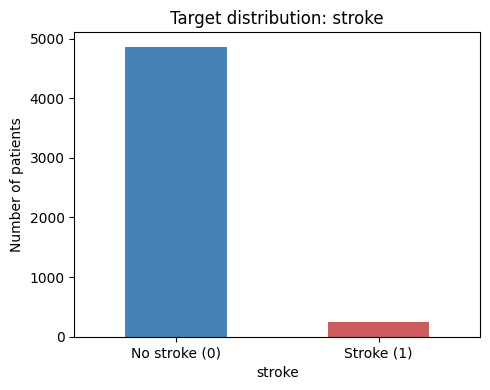

In [17]:
import matplotlib.pyplot as plt

stroke_counts = df['stroke'].value_counts()
stroke_pct = df['stroke'].value_counts(normalize=True).mul(100).round(2)
print(stroke_counts)
print(stroke_pct)

plt.figure(figsize=(5, 4))
stroke_counts.plot(kind='bar', color=['steelblue', 'indianred'])
plt.xticks([0, 1], ['No stroke (0)', 'Stroke (1)'], rotation=0)
plt.ylabel('Number of patients')
plt.title('Target distribution: stroke')
plt.tight_layout()
plt.show()

The target is heavily imbalanced: 4,861 patients (95.13%) never had a stroke, versus only
249 (4.87%) who did. This is expected for a rare medical event, but it has real consequences
downstream,  accuracy alone will be a misleading metric for any model trained on this data,
and it reinforces why I'm being careful not to casually discard any of the 249 positive
cases during cleaning.

### 3.4 Feature distributions

**Age**

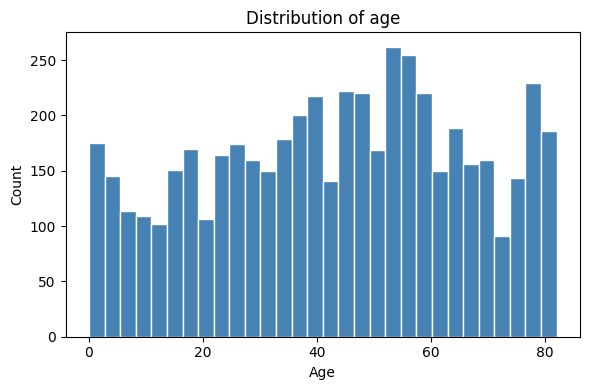

,age
count,5110.000000
mean,43.226614
std,22.612647
min,0.080000
25%,25.000000
50%,45.000000
75%,61.000000
max,82.000000


In [18]:
plt.figure(figsize=(6, 4))
plt.hist(df['age'], bins=30, color='steelblue', edgecolor='white')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Distribution of age')
plt.tight_layout()
plt.show()

df['age'].describe()

Age ranges from 0.08 to 82 years and is fairly evenly spread across adulthood, with a dip
in early childhood counts relative to adult counts, consistent with this being a general
patient population rather than an age-targeted sample.

**BMI**

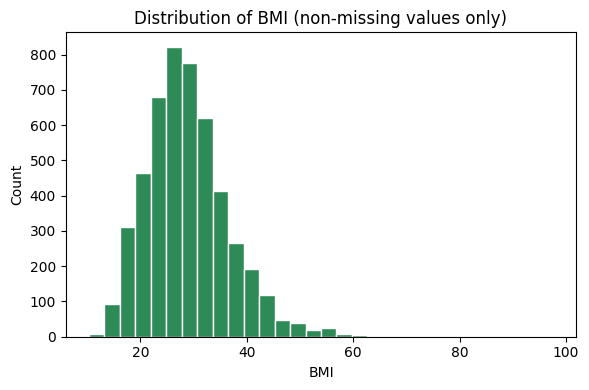

,bmi
count,4909.000000
mean,28.893237
std,7.854067
min,10.300000
25%,23.500000
50%,28.100000
75%,33.100000
max,97.600000


In [20]:
plt.figure(figsize=(6, 4))
plt.hist(df['bmi'].dropna(), bins=30, color='seagreen', edgecolor='white')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.title('Distribution of BMI (non-missing values only)')
plt.tight_layout()
plt.show()

df['bmi'].describe()

BMI is right-skewed: the median (28.1) sits below the mean (28.9), and the maximum value
(97.6) is far beyond a plausible upper bound for BMI, pulling the tail out. I think this skew will be a problem though

**Average glucose level**

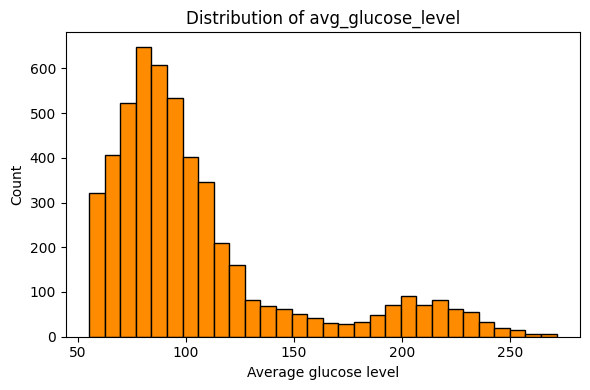

,avg_glucose_level
count,5110.000000
mean,106.147677
std,45.283560
min,55.120000
25%,77.245000
50%,91.885000
75%,114.090000
max,271.740000


In [22]:
plt.figure(figsize=(6, 4))
plt.hist(df['avg_glucose_level'], bins=30, color='darkorange', edgecolor='black')
plt.xlabel('Average glucose level')
plt.ylabel('Count')
plt.title('Distribution of avg_glucose_level')
plt.tight_layout()
plt.show()

df['avg_glucose_level'].describe()

This distribution is clearly bimodal, a large cluster of patients in the roughly
70-110 range (normal fasting glucose), and a second, smaller bump above 150-200, which likely
corresponds to diabetic or pre-diabetic patients. No values are missing here, and nothing
looks like a data-entry error (no negative or implausibly small values), so this column needs
no cleaning beyond what's already true of it.

**Smoking status (categorical)**

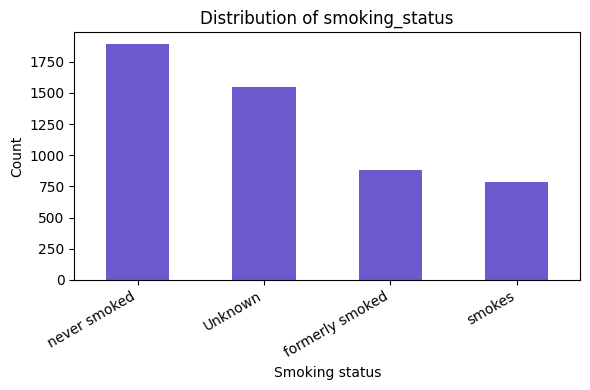

,count
smoking_status,
never smoked,1892
Unknown,1544
formerly smoked,885
smokes,789


In [23]:
plt.figure(figsize=(6, 4))
df['smoking_status'].value_counts().plot(kind='bar', color='slateblue')
plt.xlabel('Smoking status')
plt.ylabel('Count')
plt.title('Distribution of smoking_status')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

df['smoking_status'].value_counts()

"Never smoked" is the largest group (1,892), but "Unknown" is a close second (1,544 —
about 30% of the dataset). That's too large though

**Work type (categorical)**

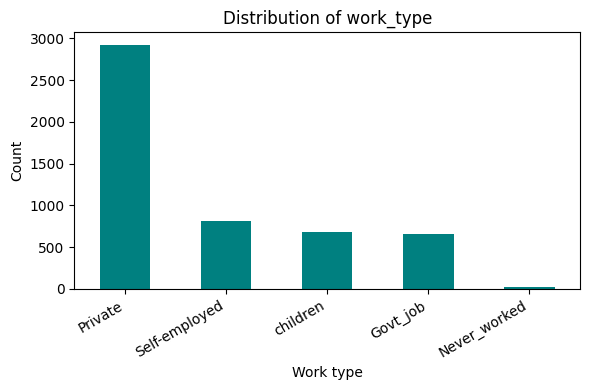

,count
work_type,
Private,2925
Self-employed,819
children,687
Govt_job,657
Never_worked,22


In [24]:
plt.figure(figsize=(6, 4))
df['work_type'].value_counts().plot(kind='bar', color='teal')
plt.xlabel('Work type')
plt.ylabel('Count')
plt.title('Distribution of work_type')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

df['work_type'].value_counts()

Most patients work in the private sector (2,925), with smaller groups that are
self-employed, government employees, or,  notably, children and patients who have never
worked. Those last two categories exist because the dataset includes minors, which is worth
keeping in mind: some "adult" risk factors (like `ever_married`) are structurally `No` for
that subgroup rather than genuinely missing information.

## 4. Data Cleaning

what i am doing here, please take note that, Every change below is applied to a working copy (`df_clean`) and justified individually.
There is no blanket `fillna()` call anywhere in this section, each column with missing or
questionable data is handled on its own terms, based on what Sections 2 and 3 revealed about
it.

In [26]:
# a copy so the original df (and the SQLite table) remain untouched as a reference
df_clean = df.copy()
print(f"Starting shape: {df_clean.shape}")

Starting shape: (5110, 12)


### 4.1 Drop the `id` column

In [27]:
df_clean = df_clean.drop(columns=['id'])

`id` is a unique patient identifier with no predictive meaning,  it's a row label, not a
feature. Keeping it around risks it accidentally leaking into a model as a spurious numeric
feature later, so it's dropped now rather than left for a future version of this notebook to
trip over.

### 4.2 Duplicate rows

In [28]:
n_dupes = df_clean.duplicated().sum()
print(f"Fully duplicated rows: {n_dupes}")

Fully duplicated rows: 0


Zero duplicate rows (and separately, `id`, actually  before it was dropped it had zero duplicate
values), so there is nothing to remove here. This is a check, not a cleaning action: I'm
stating explicitly that I looked, rather than skipping the question.

### 4.3 The single `Other` gender value that is dropped, not recoded

In [30]:
print(df_clean['gender'].value_counts())
df_clean = df_clean[df_clean['gender'] != 'Other'].copy()
print(f"\nShape after dropping the 'Other' gender row: {df_clean.shape}")

gender
Female    2994
Male      2115
Name: count, dtype: int64

Shape after dropping the 'Other' gender row: (5109, 11)


`gender` has exactly one row labeled `Other` out of 5,109. This is the one row I'm
dropping outright, for two reasons: (1) with a single example, there is no way to estimate a
stroke rate for this group that means anything statistically,  it's neither evidence for nor
against any relationship between gender and stroke; (2) folding it into `Male` or `Female`
would be fabricating a label the data doesn't support. Losing one row out of 5,110 has no
meaningful effect on the dataset as a whole, and,  unlike the BMI missingness, this row's
`stroke` value is 0, so dropping it does not remove any information about the minority class.

### 4.4 `bmi` missing values — group-median imputation, not a blanket fill

In [31]:
print(f"Missing BMI: {df_clean['bmi'].isnull().sum()} rows "
      f"({df_clean['bmi'].isnull().mean()*100:.2f}% of {len(df_clean)})")

Missing BMI: 201 rows (3.93% of 5109)



This is the column that needs the most care, for reasons already established:

- Query 4 showed BMI-missing patients have a stroke rate of **19.90%** vs. 4.26% for the rest
  — missingness is related to the outcome, so simply dropping these 201 rows would remove a
  disproportionate share of stroke-positive cases (40 of 249, or 16% of all positives) and
  worsen an already severe class imbalance. Dropping is ruled out.
- Section 3.4 showed BMI is right-skewed with implausible-looking high outliers (max 97.6), so
  a single global **mean** fill would be pulled upward by those outliers and wouldn't reflect
  a "typical" patient. A single global **median** fill is more robust to the skew, but still
  ignores that BMI varies systematically with age (children and the elderly have very
  different typical BMIs than working-age adults),  a blanket `fillna(df['bmi'].median())`
  would flatten that relationship.

Given that, the approach I'm using here is **median imputation within age decade bands**: for each
missing BMI value, i will fill it with the median BMI of *other patients in the same 10-year age
band*, rather than the dataset-wide median. This keeps the age-BMI relationship intact instead
of erasing it, without requiring a more complex model-based imputer for a capstone-scope
project.

In [32]:
# Build 10-year age bands to compute group medians
df_clean['age_band_10yr'] = (df_clean['age'] // 10 * 10).astype(int)

# Median BMI per age band, computed only from patients where BMI IS known
band_medians = df_clean.groupby('age_band_10yr')['bmi'].median()
print(band_medians)

age_band_10yr
0     18.3
10    23.4
20    26.8
30    29.7
40    30.0
50    30.5
60    30.1
70    28.8
80    27.7
Name: bmi, dtype: float64


In [33]:
# Fill missing BMI using the matching age band's median (not a single dataset-wide value)
df_clean['bmi'] = df_clean.apply(
    lambda row: band_medians[row['age_band_10yr']] if pd.isnull(row['bmi']) else row['bmi'],
    axis=1
)

# Drop the helper column now that it's done its job
df_clean = df_clean.drop(columns=['age_band_10yr'])

print(f"Remaining missing BMI values: {df_clean['bmi'].isnull().sum()}")

Remaining missing BMI values: 0


All 201 missing BMI values are now filled using the median for their own age decade,
rather than one dataset-wide number. Zero rows were dropped for this issue, in line with the
reasoning above.

### 4.5 `smoking_status` — \"Unknown\" is kept as its own category, not treated as missing

In [34]:
df_clean['smoking_status'].value_counts()

,count
smoking_status,
never smoked,1892
Unknown,1544
formerly smoked,884
smokes,789


`Unknown` is not a null value in this dataset, it's an explicit string the data
collectors used, and it accounts for ~30% of all rows (1,544). Two things rule out touching it
here: dropping these rows would discard nearly a third of the dataset for no justified reason,
and Query 3 plus the work-type breakdown in Section 3.4 both suggest this category is
concentrated among younger patients (including children who were never asked about smoking)...
so it's not random missingness that needs "fixing," it's a real, meaningful category in its
own right. No change is made to this column.

### 4.6 Numeric ranges — sanity checks, no changes needed

In [36]:
print("Age range:", df_clean['age'].min(), "-", df_clean['age'].max())
print("avg_glucose_level range:", df_clean['avg_glucose_level'].min(), "-", df_clean['avg_glucose_level'].max())
print("BMI range after imputation:", df_clean['bmi'].min(), "-", df_clean['bmi'].max())

Age range: 0.08 - 82.0
avg_glucose_level range: 55.12 - 271.74
BMI range after imputation: 10.3 - 97.6


Age (0.08-82) and glucose (55.12-271.74) both fall within medically plausible bounds, so
neither is capped or removed. The maximum BMI (97.6) is extreme but not impossible, i think severe
obesity cases do reach this range, and since it's a real recorded value rather than a
missing one, I'm leaving it in rather than treating it as an error I have no evidence for.
Flagging it here so it isn't a silent decision, even though the action taken is to leave it as is.

### 4.7 Final check

In [37]:
print(f"Final shape: {df_clean.shape}")
print(f"Rows dropped overall: {df.shape[0] - df_clean.shape[0]} "
      f"(the single 'Other' gender row)")
print(f"Missing values remaining:\n{df_clean.isnull().sum().sum()}")
df_clean.head()

Final shape: (5109, 11)
Rows dropped overall: 1 (the single 'Other' gender row)
Missing values remaining:
0


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,30.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [38]:
# Optionally, persist the cleaned version alongside the raw table for later use
df_clean.to_sql('patients_clean', conn, if_exists='replace', index=False)
pd.read_sql("SELECT COUNT(*) AS row_count FROM patients_clean;", conn)

,row_count
0,5109


## 5. Feature Engineering

Four new features (more than the minimum of three), each built for a specific reason rather
than "because it's possible." All are derived from `df_clean` and added onto it directly.

### 5.1 `age_group` — binning a continuous column into clinical life stages

In [39]:
bins = [0, 18, 40, 60, 80, 100]
labels = ['child_0_17', 'young_adult_18_39', 'middle_aged_40_59', 'senior_60_79', 'elderly_80_plus']

df_clean['age_group'] = pd.cut(df_clean['age'], bins=bins, labels=labels, right=False)

df_clean.groupby('age_group', observed=True)['stroke'].agg(['count', 'mean']).rename(columns={'mean': 'stroke_rate'})

,count,stroke_rate
age_group,,
child_0_17,856,0.002336
young_adult_18_39,1313,0.004570
middle_aged_40_59,1564,0.038363
senior_60_79,1190,0.118487
elderly_80_plus,186,0.215054


**My reasoning:** Query 1 in Part 1 already showed stroke risk doesn't move smoothly
with age, it jumps between roughly defined life stages (near-zero for anyone under 40, then a
step up in the 40s-50s, another step in the 60s-70s, and a much sharper one past 80). A raw
`age` feature forces a model to learn that step pattern purely from a linear or continuous
signal, which is harder than it needs to be. Binning into clinically recognizable groups,
child, young adult, middle-aged, senior, elderly — does two things: it hands a tree-based or
linear model an explicit signal aligned with the natural risk tiers already visible in the
data (0.23% → 0.46% → 3.84% → 11.85% → 21.51% stroke rate across the five bins), and it's a
feature a clinician or stakeholder can immediately interpret without needing to translate a
numeric age into what it means for risk.

### 5.2 `risk_factor_count`... counting risk flags present per row

In [41]:
df_clean['risk_factor_count'] = (
    df_clean['hypertension'] +
    df_clean['heart_disease'] +
    (df_clean['smoking_status'] == 'smokes').astype(int)
)

df_clean.groupby('risk_factor_count')['stroke'].agg(['count', 'mean']).rename(columns={'mean': 'stroke_rate'})

,count,stroke_rate
risk_factor_count,,
0,3750,0.034133
1,1170,0.078632
2,174,0.137931
3,15,0.333333


**My reasoning:** `hypertension`, `heart_disease`, and current smoking are three
independent, clinically established stroke risk factors, each currently living in its own
column. This feature counts how many of the three a given patient has (0 to 3), turning three
separate binary flags into one simple risk score. The payoff shows up immediately in the
stroke rate by count: 3.41% with zero risk factors, 7.86% with one, 13.79% with two, and
33.33% with all three, a clean, monotonic climb. That kind of single, easy-to-explain score
is exactly the sort of thing a non-technical stakeholder (or a triage tool) can act on
directly, rather than needing to reason about three columns at once.

### 5.3 `glucose_bmi_ratio`  a ratio feature combining two metabolic signals

In [42]:
df_clean['glucose_bmi_ratio'] = df_clean['avg_glucose_level'] / df_clean['bmi']

df_clean['glucose_bmi_ratio'].describe()

,glucose_bmi_ratio
count,5109.000000
mean,3.859057
std,1.710112
min,0.618478
25%,2.632627
50%,3.435223
75%,4.662121
max,16.054930


**My reasoning:** `avg_glucose_level` and `bmi` are both metabolic signals, but on
their own each only tells part of the story,  a patient can have a high BMI with normal
glucose, or elevated glucose with a normal BMI, and those are clinically different situations
than having both elevated together. Dividing glucose by BMI produces a single number that's
high specifically when glucose is elevated *relative to* body mass, which is closer to what a
clinician means by "metabolic strain" than either raw column alone. To be transparent about
its performance rather than just its rationale: its linear correlation with `stroke` (0.07) is
modest on its own,  the value of a ratio feature like this tends to show up more in how it
interacts with other features inside a model than as a standalone predictor, so it's included
as a candidate feature rather than a guaranteed win.

### 5.4 `age_x_hypertension` — an interaction term

In [43]:
df_clean['age_x_hypertension'] = df_clean['age'] * df_clean['hypertension']

df_clean['age_x_hypertension'].describe()

,age_x_hypertension
count,5109.000000
mean,6.067332
std,18.977230
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,82.000000


**My reasoning:** Query 2 in Part 1 showed hypertension's effect on stroke risk
isn't constant, it compounds with other risk factors rather than adding a flat amount. This
term is zero for every non-hypertensive patient and equal to their age for every hypertensive
patient, so it specifically captures "how much hypertension exposure, weighted by age" rather
than treating a 30-year-old and an 80-year-old with hypertension as equivalent. In this
dataset its correlation with `stroke` (0.15) is actually weaker than `age` alone (0.25),  worth
stating plainly rather than glossing over, since `hypertension` is disproportionately common
in the older patients who already drive most of the raw age signal. It's kept anyway because
linear correlation alone won't show an interaction effect that a model can otherwise exploit
directly; if it doesn't earn its place during feature selection later, it's cheap to drop.

## 6. Encoding Categorical Columns

Every categorical column gets encoded, the choice between label encoding and one-hot encoding
is made per column, based on whether the categories have a real order and how many categories
each column has.

In [44]:
df_encoded = df_clean.copy()

# Quick inventory of every categorical column before deciding how to encode each one
cat_cols = df_encoded.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
for col in cat_cols:
    print(f"{col}: {df_encoded[col].nunique()} categories -> {list(df_encoded[col].unique())}")

gender: 2 categories -> ['Male', 'Female']
ever_married: 2 categories -> ['Yes', 'No']
work_type: 5 categories -> ['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked']
Residence_type: 2 categories -> ['Urban', 'Rural']
smoking_status: 4 categories -> ['formerly smoked', 'never smoked', 'smokes', 'Unknown']
age_group: 5 categories -> ['senior_60_79', 'elderly_80_plus', 'middle_aged_40_59', 'young_adult_18_39', 'child_0_17']


### 6.1 Binary columns,  label encoded (0/1)

In [45]:
# gender: Male / Female -> label encode. With exactly two categories and no inherent
# order, one-hot encoding here would just produce two perfectly redundant columns
# (gender_Male == 1 - gender_Female), so a single 0/1 column captures the same
# information with no wasted dimensionality.
df_encoded['gender'] = df_encoded['gender'].map({'Female': 0, 'Male': 1})

# ever_married: Yes / No -> same logic, binary with no order.
df_encoded['ever_married'] = df_encoded['ever_married'].map({'No': 0, 'Yes': 1})

# Residence_type: Urban / Rural -> same logic again.
df_encoded['Residence_type'] = df_encoded['Residence_type'].map({'Rural': 0, 'Urban': 1})

df_encoded[['gender', 'ever_married', 'Residence_type']].head()

,gender,ever_married,Residence_type
0,1,1,1
1,0,1,0
2,1,1,0
3,0,1,1
4,0,1,0


**Why label encoding here:** this is for a strictly two-category column, label encoding and
one-hot encoding carry identical information — the only difference is that one-hot would add a
second, perfectly collinear column for no benefit. Since none of these three columns have more
than two categories, and none imply any order (there's no sense in which "Urban" is
numerically "more" than "Rural"), a single 0/1 column is the simplest correct choice.

### 6.2 `age_group`,  ordinal label encoding (order is preserved on purpose)

In [46]:
age_group_order = ['child_0_17', 'young_adult_18_39', 'middle_aged_40_59', 'senior_60_79', 'elderly_80_plus']

df_encoded['age_group'] = pd.Categorical(df_encoded['age_group'], categories=age_group_order, ordered=True).codes

df_encoded['age_group'].value_counts().sort_index()

,count
age_group,
0,856
1,1313
2,1564
3,1190
4,186


**Why ordinal (not one-hot) here:** unlike the other categorical columns, `age_group`
has a genuine, meaningful order,  `child_0_17` < `young_adult_18_39` < ... < `elderly_80_plus`
 and Section 5.1 showed stroke risk increases monotonically across that order. Encoding it as
one-hot would throw away that ordering information and force a model to relearn it from
scratch across five separate columns. Using `pd.Categorical(..., ordered=True).codes` instead
of plain `sklearn.LabelEncoder` is a deliberate choice too , `LabelEncoder` assigns integers in
whatever order it encounters the categories (typically alphabetical), which would *not*
match the actual age order here and would silently corrupt the feature.

### 6.3 `work_type` and `smoking_status` one-hot encoded, `drop_first=True`

In [47]:
df_encoded = pd.get_dummies(
    df_encoded,
    columns=['work_type', 'smoking_status'],
    prefix=['work', 'smoking'],
    drop_first=True
)

df_encoded.filter(regex='^(work_|smoking_)').head()

,work_Never_worked,work_Private,work_Self-employed,work_children,smoking_formerly smoked,smoking_never smoked,smoking_smokes
0,False,True,False,False,True,False,False
1,False,False,True,False,False,True,False
2,False,True,False,False,False,True,False
3,False,True,False,False,False,False,True
4,False,False,True,False,False,True,False


**Why one-hot (not label encoding) here:** `work_type` (`Private`, `Self-employed`,
`Govt_job`, `children`, `Never_worked`) has no meaningful numeric order , there's no sense in
which `Govt_job` is "more" or "less" than `Self-employed`,  so label-encoding it as 0-4 would
invent a false ranking that a linear model could pick up on as if it meant something. The same
applies to `smoking_status`: it might look ordinal at a glance (`never smoked` → `formerly
smoked` → `smokes`), but `Unknown` doesn't fit anywhere on that scale, so treating the whole
column as ordered would misrepresent nearly a third of the dataset. One-hot avoids inventing an
order that isn't really there for either column.

**Why `drop_first=True`:** for a column with *k* categories, only *k-1* dummy columns are
needed, the dropped category is fully recoverable as "all the other dummies are 0," so
keeping all *k* would be redundant (the dummy variable trap) and would introduce perfect
multicollinearity, which is a real problem for linear/logistic models even though tree-based
models tend to tolerate it. Dropping the first category by default costs nothing in
information and keeps the feature space smaller, so it's applied here for both columns.

In [48]:
print(f"Shape before encoding: {df_clean.shape}")
print(f"Shape after encoding: {df_encoded.shape}")
df_encoded.dtypes

Shape before encoding: (5109, 15)
Shape after encoding: (5109, 20)


,0
gender,int64
age,float64
hypertension,int64
heart_disease,int64
ever_married,int64
Residence_type,int64
avg_glucose_level,float64
bmi,float64
stroke,int64
age_group,int8


## 7. Scaling the Features

Only the continuous numeric columns need scaling, binary flags and one-hot dummies are
already on a 0/1 scale and don't need it. The candidates here are `age`, `avg_glucose_level`,
`bmi`, `glucose_bmi_ratio`, and `age_x_hypertension`.

In [49]:
numeric_cols_to_scale = ['age', 'avg_glucose_level', 'bmi', 'glucose_bmi_ratio', 'age_x_hypertension']
df_encoded[numeric_cols_to_scale].describe()

,age,avg_glucose_level,bmi,glucose_bmi_ratio,age_x_hypertension
count,5109.000000,5109.000000,5109.000000,5109.000000,5109.000000
mean,43.229986,106.140399,28.877471,3.859057,6.067332
std,22.613575,45.285004,7.722932,1.710112,18.977230
min,0.080000,55.120000,10.300000,0.618478,0.000000
25%,25.000000,77.240000,23.700000,2.632627,0.000000
50%,45.000000,91.880000,28.300000,3.435223,0.000000
75%,61.000000,114.090000,32.800000,4.662121,0.000000
max,82.000000,271.740000,97.600000,16.054930,82.000000


**StandardScaler vs. MinMaxScaler:** the deciding factor is the outliers already
documented in Part 1's EDA. `bmi` has a right-skewed distribution with a maximum of 97.6
against a median of 28.1, `avg_glucose_level` is bimodal with a long tail out past 250, and
`age_x_hypertension` is zero for the ~90% of patients without hypertension and only non-zero
(up to 82) for the rest, its own kind of extreme, lopsided spread. `MinMaxScaler` rescales
everything based on the *observed min and max*, so a handful of extreme values would compress
the bulk of ordinary patients into a narrow slice of the 0-1 range, reducing the resolution the
model has to distinguish between them. `StandardScaler` instead centers on the mean and scales
by standard deviation, which is far less sensitive to a small number of extreme values pulling
the range around,  it's the more appropriate choice whenever a feature has meaningful outliers
rather than a bounded, roughly uniform range. **StandardScaler is used here** for exactly that
reason.

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_encoded[numeric_cols_to_scale] = scaler.fit_transform(df_encoded[numeric_cols_to_scale])

df_encoded[numeric_cols_to_scale].describe()

,age,avg_glucose_level,bmi,glucose_bmi_ratio,age_x_hypertension
count,5.109000e+03,5.109000e+03,5.109000e+03,5.109000e+03,5.109000e+03
mean,7.231987e-17,-1.613289e-16,8.900907e-17,7.788294e-17,5.563067e-18
std,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00
min,-1.908332e+00,-1.126761e+00,-2.405730e+00,-1.895136e+00,-3.197477e-01
25%,-8.062312e-01,-6.382516e-01,-6.704679e-01,-7.172334e-01,-3.197477e-01
50%,7.827984e-02,-3.149342e-01,-7.478088e-02,-2.478641e-01,-3.197477e-01
75%,7.858887e-01,1.755632e-01,5.079564e-01,4.696435e-01,-3.197477e-01
max,1.714625e+00,3.657189e+00,8.899374e+00,7.132320e+00,4.001643e+00


After scaling, each of these five columns has a mean of ~0 and a standard deviation of 1, on a comparable scale to the binary and one-hot columns, which prevents any single raw-value
column (like `avg_glucose_level`, previously ranging up to 271) from dominating a
distance-based or gradient-based model simply because of its original units.

### 7.1 Final feature set

In [51]:
print(f"Final shape ready for modeling: {df_encoded.shape}")
df_encoded.head()

Final shape ready for modeling: (5109, 20)


,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,age_group,risk_factor_count,glucose_bmi_ratio,age_x_hypertension,work_Never_worked,work_Private,work_Self-employed,work_children,smoking_formerly smoked,smoking_never smoked,smoking_smokes
0,1,1.051242,0,1,1,1,2.706450,1.000046,1,3,1,1.397299,-0.319748,False,True,False,False,True,False,False
1,0,0.785889,0,0,1,0,2.121652,0.158314,1,3,0,1.671916,-0.319748,False,False,True,False,False,True,False
2,1,1.626174,0,1,1,0,-0.004867,0.469107,1,4,1,-0.350877,-0.319748,False,True,False,False,False,True,False
3,0,0.255182,0,0,1,1,1.437473,0.715152,1,2,1,0.654150,-0.319748,False,True,False,False,False,False,True
4,0,1.581949,1,0,1,0,1.501297,-0.631619,1,3,1,1.985996,3.843543,False,False,True,False,False,True,False


In [52]:
# Persist the fully engineered, encoded, and scaled table for the modeling stage
df_encoded.to_sql('patients_model_ready', conn, if_exists='replace', index=False)
pd.read_sql("SELECT COUNT(*) AS row_count FROM patients_model_ready;", conn)

,row_count
0,5109


## 8. Clustering Analysis

The goal here is unsupervised: find natural patient groupings *without* using the `stroke`
label, then see afterward whether those groupings line up with stroke risk. `stroke` itself is
therefore excluded from the clustering features.

### 8.1 Choosing which features to cluster on

In [53]:
cluster_feature_cols = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'ever_married']

# age, avg_glucose_level, and bmi were already StandardScaler-transformed in Section 7.
# hypertension, heart_disease, and ever_married are already clean 0/1 flags.
# No further scaling is needed here, reusing the same scaled values keeps this
# consistent with the rest of the notebook rather than re-fitting a second scaler.
X_cluster = df_encoded[cluster_feature_cols].copy()
X_cluster.describe()

,age,avg_glucose_level,bmi,hypertension,heart_disease,ever_married
count,5.109000e+03,5.109000e+03,5.109000e+03,5109.000000,5109.000000,5109.000000
mean,7.231987e-17,-1.613289e-16,8.900907e-17,0.097475,0.054022,0.656293
std,1.000098e+00,1.000098e+00,1.000098e+00,0.296633,0.226084,0.474991
min,-1.908332e+00,-1.126761e+00,-2.405730e+00,0.000000,0.000000,0.000000
25%,-8.062312e-01,-6.382516e-01,-6.704679e-01,0.000000,0.000000,0.000000
50%,7.827984e-02,-3.149342e-01,-7.478088e-02,0.000000,0.000000,1.000000
75%,7.858887e-01,1.755632e-01,5.079564e-01,0.000000,0.000000,1.000000
max,1.714625e+00,3.657189e+00,8.899374e+00,1.000000,1.000000,1.000000


**Why these six columns, and not all 19 engineered/encoded features:** K-Means measures
distance between points, and every feature included pulls on that distance equally, so the
feature set needs to be a deliberate choice, not "everything we have."

- `age`, `avg_glucose_level`, `bmi`, `hypertension`, `heart_disease`, `ever_married` are kept
  because they're the core clinical and demographic signals, already on comparable scales, and
  each one is independently meaningful.
- `risk_factor_count` and `age_x_hypertension` are **excluded** because they're built directly
  from `hypertension`, `heart_disease`, and `age`,  including both the raw columns and features
  derived from them would double-count the same underlying signal and distort the distances.
- `work_type` and `smoking_status` one-hot dummies are **excluded** because a handful of sparse
  0/1 dummy columns can dominate a Euclidean distance calculation in ways that don't correspond
  to meaningful clinical separation,  a patient's job category shouldn't outweigh their actual
  vital signs when deciding which cluster they belong to.
- `age_group` is **excluded** because it's a discretized version of `age`, which is already in
  the feature set in its original, more precise form.

### 8.2 K-Means for K = 2 to 10  elbow curve and silhouette scores

In [54]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range = range(2, 11)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, cluster_labels))

results = pd.DataFrame({'K': list(K_range), 'inertia': inertias, 'silhouette_score': sil_scores})
results

,K,inertia,silhouette_score
0,2,11717.530685,0.294836
1,3,8054.838319,0.362342
2,4,6383.667042,0.344515
3,5,5592.861286,0.291050
4,6,5142.304289,0.279589
5,7,4751.429308,0.267084
6,8,4386.156803,0.261073
7,9,4137.593826,0.265443
8,10,3944.177045,0.249850


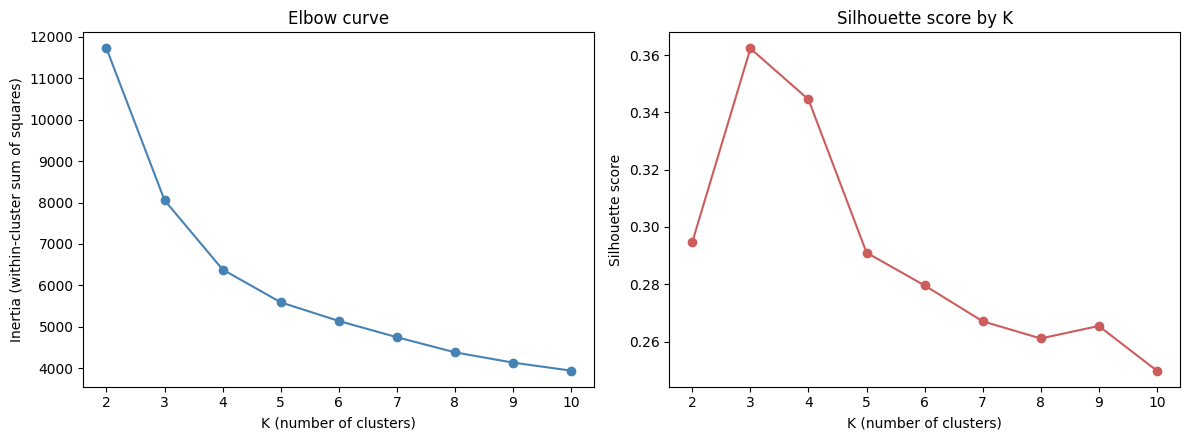

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(K_range, inertias, marker='o', color='steelblue')
axes[0].set_xlabel('K (number of clusters)')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].set_title('Elbow curve')
axes[0].set_xticks(list(K_range))

axes[1].plot(K_range, sil_scores, marker='o', color='indianred')
axes[1].set_xlabel('K (number of clusters)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score by K')
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.show()

**Reading both signals** (values as produced by the cells above):

| K | Inertia | Drop from previous K | Silhouette |
|---|---|---|---|
| 2 | 11,717.5 | — | 0.295 |
| 3 | 8,054.8 | -31.3% | **0.362** |
| 4 | 6,383.7 | -20.7% | 0.345 |
| 5 | 5,592.9 | -12.4% | 0.291 |
| 6 | 5,142.3 | -8.1% | 0.280 |
| 7 | 4,751.4 | -7.6% | 0.267 |
| 8 | 4,386.2 | -7.7% | 0.261 |
| 9 | 4,137.6 | -5.7% | 0.265 |
| 10 | 3,944.2 | -4.7% | 0.250 |

- **Elbow curve:** the drop in inertia is still large from K=3 to K=4 (-20.7%), then falls off
  sharply after that, the K=4-to-5 step only buys -12.4%, and every step from K=5 onward stays
  in the -5% to -8% range. That's the elbow: the last point where adding a cluster still
  meaningfully tightens the groups is **K=4**.
- **Silhouette score:** the single highest value across the whole range is at K=3 (0.362), with
  K=4 a close second (0.345); both clearly ahead of K=5 and beyond, which drop to 0.29 and
  keep falling.

The two signals don't point at exactly the same K, and that's worth being upfront about rather
than glossing over: silhouette is technically best at K=3, while the elbow's last big gain is
at K=4. K=4 is the value where both signals are still strong together,  it's the elbow's own
answer, and its silhouette score (0.345) is only 0.017 below K=3's peak, well ahead of
everything from K=5 on. K=3 would be the "purest cluster separation" choice, but K=4 was
selected because it captures materially more structure than K=3 (the sharp inertia drop from
3→4) for almost no cost in silhouette quality.

### 8.3 Final K = 4

In [56]:
K_FINAL = 4

kmeans_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_cluster)

df_clustered = df_encoded.copy()
df_clustered['cluster'] = cluster_labels

df_clustered['cluster'].value_counts().sort_index()

,count
cluster,
0,1500
1,882
2,668
3,2059


**Why K=4, stated plainly:** the elbow shows the last substantial gain in cluster
tightness happens going from 3 to 4 clusters (a 20.7% drop in inertia), after which returns
flatten out quickly. The silhouette score at K=4 (0.345) is nearly as strong as the technical
peak at K=3 (0.362) and comfortably ahead of K=5 and beyond. K=4 is the point where the elbow's
last meaningful improvement and a still-strong silhouette score line up.

### 8.4 Profiling each cluster

In [57]:
profile_cols = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease',
                'ever_married', 'risk_factor_count', 'stroke']

# Note: age, avg_glucose_level, and bmi are shown here in their *scaled* form (mean ~0),
# since that's what df_encoded and the clustering itself actually used. hypertension,
# heart_disease, ever_married, and risk_factor_count are on their original 0/1 or count
# scale, and stroke is included last purely to see how the label distributes across
# clusters it never saw.
cluster_profile = df_clustered.groupby('cluster')[profile_cols].mean().round(3)
cluster_profile['count'] = df_clustered.groupby('cluster').size()
cluster_profile

,age,avg_glucose_level,bmi,hypertension,heart_disease,ever_married,risk_factor_count,stroke,count
cluster,,,,,,,,,
0,-1.198,-0.284,-0.826,0.003,0.001,0.121,0.097,0.002,1500
1,-0.062,-0.349,1.358,0.101,0.022,0.757,0.322,0.018,882
2,0.781,2.232,0.526,0.259,0.159,0.901,0.588,0.133,668
3,0.646,-0.368,-0.150,0.112,0.072,0.923,0.360,0.068,2059


**Reading the profile (scaled `age`/`avg_glucose_level`/`bmi` — positive means above the
dataset average, negative means below):**

| Cluster | Size | Profile | Stroke rate |
|---|---|---|---|
| 0 | 1,500 | Youngest group (age z ≈ -1.20), below-average BMI, only 12% ever married, essentially no comorbidities | 0.2% |
| 1 | 882 | Near-average age, by far the **highest BMI** (z ≈ +1.36), below-average glucose, low comorbidities | 1.8% |
| 2 | 668 | Older (age z ≈ +0.78), by far the **highest glucose** (z ≈ +2.23), highest hypertension (26%) and heart disease (16%) rates | **13.3%** |
| 3 | 2,059 | Second-oldest group, **highest marriage rate** (92%), near-average BMI, below-average glucose, moderate comorbidities | 6.8% |

**Plain-English cluster names:**

- **Cluster 0: "Unmarried youth and children."** The clearest-cut group: youngest by a wide
  margin, almost never married, virtually no diagnosed hypertension or heart disease, and the
  lowest stroke rate of any cluster (0.2%).
- **Cluster 1: "Higher-BMI adults, otherwise low risk."** Distinguished almost entirely by
  BMI — the highest of any cluster — while age, glucose, and comorbidity rates stay close to
  or below average. Stroke rate (1.8%) is low, suggesting elevated BMI alone, without the
  other risk factors, isn't driving much risk in this population.
- **Cluster 2: "High-risk older adults.. elevated glucose and comorbidities."** The smallest
  cluster and clinically the most concerning: glucose is far above every other group, and this
  cluster also has the highest rates of hypertension and heart disease. Its stroke rate
  (13.3%) is more than 6x the dataset average and the highest of the four clusters, the group
  a screening program would prioritize first.
- **Cluster 3: "Married older adults, average risk."** The largest cluster. Skews older and
  is overwhelmingly married, but glucose and BMI sit close to the dataset average and
  comorbidity rates are moderate. Its stroke rate (6.8%) sits in between the low-risk and
  high-risk clusters, a "typical older adult" baseline rather than a flagged group.

None of this used the `stroke` column to form the clusters — it only shows up in the last
column of the profile table as a check. The fact that stroke rate increases in a sensible,
clinically coherent order across these four *unsupervised* groups (0.2% → 1.8% → 6.8% → 13.3%)
is a good sign the clustering found something real rather than noise.

### 8.5 Visualizing the clusters in 2D with PCA

In [58]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
principal_components = pca.fit_transform(X_cluster)

df_clustered['pca_1'] = principal_components[:, 0]
df_clustered['pca_2'] = principal_components[:, 1]

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total variance explained by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%")

Variance explained by PC1: 47.5%
Variance explained by PC2: 25.3%
Total variance explained by 2 components: 72.8%


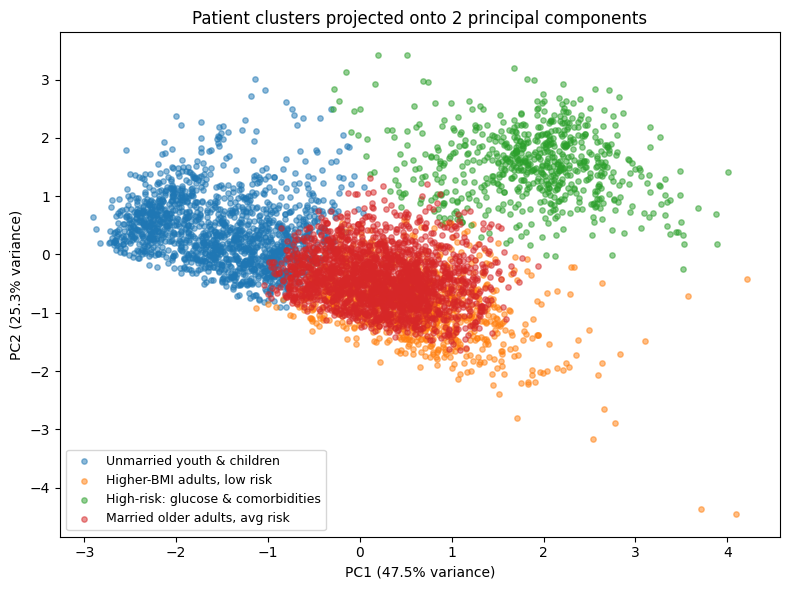

In [59]:
cluster_names = {
    0: 'Unmarried youth & children',
    1: 'Higher-BMI adults, low risk',
    2: 'High-risk: glucose & comorbidities',
    3: 'Married older adults, avg risk'
}

plt.figure(figsize=(8, 6))
colors = plt.cm.tab10(range(K_FINAL))

for cluster_id in range(K_FINAL):
    subset = df_clustered[df_clustered['cluster'] == cluster_id]
    plt.scatter(subset['pca_1'], subset['pca_2'], s=15, alpha=0.5,
                color=colors[cluster_id], label=cluster_names[cluster_id])

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Patient clusters projected onto 2 principal components')
plt.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

The two principal components together capture about 72.8% of the total variance in the
six clustering features,  a strong 2D summary of the underlying structure. In the plot, the
youngest cluster (0) separates clearly along one axis from the three older clusters, while
Cluster 2 (elevated glucose and comorbidities) sits visibly apart from Cluster 3 (married,
average risk) along the other axis,  consistent with glucose, rather than age alone, being the
main thing that separates the two mid-to-high-risk older groups from each other.

**Summary of Part 3:**

| Step | Choice | Justification |
|---|---|---|
| Clustering features | 6 core clinical/demographic columns, `stroke` and derived features excluded | Avoids double-counting engineered features and diluting distance with sparse dummies |
| K selection | K=4 | Elbow's last major gain is at K=4 (-20.7% inertia); silhouette at K=4 (0.345) is a close second to K=3's peak (0.362) and well ahead of K=5+ |
| Cluster profiling | Group means on original-scale clinical features | Reveals 4 clinically distinct, plain-English-nameable patient segments |
| Visualization | PCA to 2 components (~72.8% variance explained) | Confirms visual separation between the low-risk and high-risk groups |

The clustering was built with no knowledge of `stroke`, yet the four groups it found line up
in a clean, clinically sensible order of stroke risk — a useful sanity check that the feature
engineering in Part 2 captured signal that actually matters.

## 9. Classification

The goal now is supervised: predict `stroke` directly. This section sets up the train/test
split, trains three classifiers, and compares them on the metrics that actually matter for a
severely imbalanced medical outcome, not just accuracy.

### 9.1 Train/test split: single stratified split, not cross-validation

In [60]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['stroke'])
y = df_encoded['stroke']

print(f"Total rows available: {len(df_encoded)}")
print(f"Overall stroke rate: {y.mean()*100:.2f}%")

Total rows available: 5109
Overall stroke rate: 4.87%


**Split strategy, decided by row count:** this dataset has 5,109 rows, well above the
2,000-row threshold, so a single train/test split is used rather than stratified k-fold
cross-validation. With this many rows, a held-out test set is large enough (1,022 rows at an
80/20 split) to give a stable estimate of performance on its own, and cross-validation's main
benefit, averaging out the noise from a small, unstable test set, matters far less here than
it would on a dataset small enough to make any single split's results shaky.

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # preserves the ~4.87% stroke rate in both the train and test sets
)

print(f"Train set: {X_train.shape[0]} rows, stroke rate {y_train.mean()*100:.2f}%")
print(f"Test set:  {X_test.shape[0]} rows, stroke rate {y_test.mean()*100:.2f}%")

Train set: 4087 rows, stroke rate 4.87%
Test set:  1022 rows, stroke rate 4.89%


**Why I use `stratify=y` specifically:** the target is heavily imbalanced , only 4.87% of
patients had a stroke. A plain random split risks pulling a disproportionate share of the 249
positive cases into one side of the split purely by chance, especially in the smaller test set;
in the worst case a test set could end up with far fewer (or more) positive examples than the
true rate, making every metric computed on it unreliable. `stratify=y` forces both the train
and test sets to preserve the same ~4.87% stroke rate seen in the full dataset (confirmed
above: 4.87% in train, 4.89% in test), so the test set is a fair, representative sample rather
than a lucky or unlucky one.

### 9.2 Training three classifiers

Three classifiers, each chosen for a different reason rather than just "these are the
ones covered in class":

- **Logistic Regression** : the natural baseline for a binary medical outcome. It's linear and
  interpretable: each coefficient has a direct, explainable direction and magnitude, which
  matters in a healthcare context where a model's reasoning may need to be justified to a
  clinician. It also pairs naturally with the `StandardScaler`-scaled features already built in
  Part 2, since logistic regression's coefficients are only comparable across features when
  they're on the same scale.
- **Decision Tree**: captures non-linear relationships and interactions (e.g., "risk is high
  only when hypertension AND age are both elevated") that a linear model can't represent
  without hand-built interaction terms. It's also the most directly explainable of the three to
  a non-technical audience, a specific decision path can be traced and shown to a
  stakeholder, and its logic connects naturally to the rule-like patient segments already
  found by clustering in Part 3.
- **Random Forest**: an ensemble of many decision trees, included specifically as a check on
  whether a single tree's decisions are stable or just an artifact of one particular split of
  the data. Averaging many trees typically reduces the overfitting and variance a single deep
  tree is prone to, and it's a standard, well-understood step up in complexity from the two
  simpler models above.

All three use `class_weight='balanced'`, which reweights the loss function so that
misclassifying the rare positive (stroke) class costs proportionally more than misclassifying
the common negative class,  without this, a model trained on data that's 95% negative can score
high on accuracy simply by predicting "no stroke" for everyone, which would be useless for the
actual goal of catching at-risk patients.

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=6, class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=8, class_weight='balanced', random_state=42
    ),
}

# max_depth is capped on the tree-based models to keep them from memorizing the
# training set outright, given how few positive examples (only ~199 in the training
# set) there are to learn from.
for name, model in models.items():
    model.fit(X_train, y_train)
print("All three models trained.")

All three models trained.


### 9.3 Metrics and confusion matrix, per model

In [64]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

metric_rows = []
predictions = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    predictions[name] = (y_pred, y_proba)

    metric_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_proba),
    })

comparison_table = pd.DataFrame(metric_rows).set_index('Model').round(4)
comparison_table

,Accuracy,Precision,Recall,F1,ROC AUC
Model,,,,,
Logistic Regression,0.7387,0.1371,0.82,0.2350,0.8435
Decision Tree,0.7025,0.1128,0.74,0.1958,0.7443
Random Forest,0.8571,0.1883,0.58,0.2843,0.8171


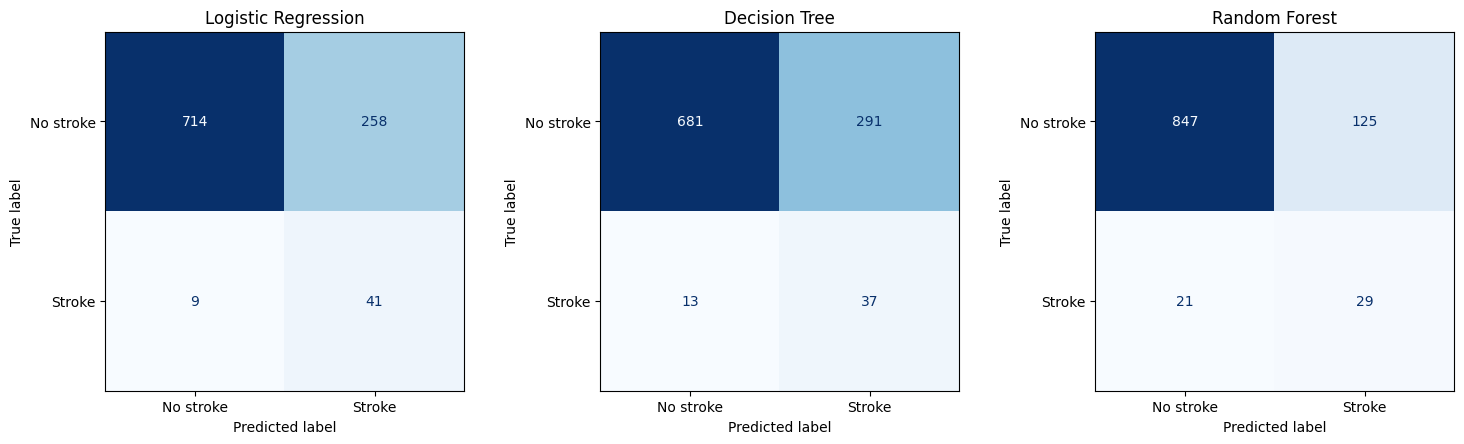

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred, _ = predictions[name]
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No stroke', 'Stroke'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

**Reading the results (from the comparison table and confusion matrices above):**

- **Logistic Regression** gets the highest recall (0.82) and the highest ROC AUC (0.844) of
  the three. It correctly flags 41 of the 50 actual stroke cases in the test set, at the cost
  of a lot of false alarms (258 patients flagged who didn't have a stroke)  precision is low
  (0.137) as a direct result. Given `class_weight='balanced'` was applied specifically to
  prioritize catching positives, this is the model behaving as configured, not a flaw.
- **Decision Tree** is the weakest of the three on every metric (ROC AUC 0.744, F1 0.196). A
  single tree, even depth-capped, tends to be less stable than an ensemble — it's included
  mainly as the interpretable baseline that Random Forest is built from, and comparing the two
  shows exactly what ensembling buys here.
- **Random Forest** trades recall for precision compared to Logistic Regression: it catches
  fewer of the actual stroke cases (29 of 50, recall 0.58) but flags far fewer healthy patients
  incorrectly (125 false positives vs. 258), giving it the best accuracy (0.857) and the best
  F1 score (0.284) of the three. Its ROC AUC (0.817) is close to, but still behind, Logistic
  Regression's.

**Which metric matters most here is a judgment call, not a fact:** in a stroke-screening
context, missing an actual stroke case (a false negative) is typically far more costly than
one extra unnecessary follow-up test (a false positive)  which favors Logistic Regression's
high recall. But a real deployment would also need to weigh the cost of 258 unnecessary
follow-ups against 41 true positives caught, which is a decision for clinicians and
stakeholders, not something the model itself can settle. Accuracy alone (which Random Forest
"wins" on) is the least useful metric of the five here, precisely because it's the one most
inflated by the 95%-negative class imbalance.

### 9.4 ROC curves all three models compared

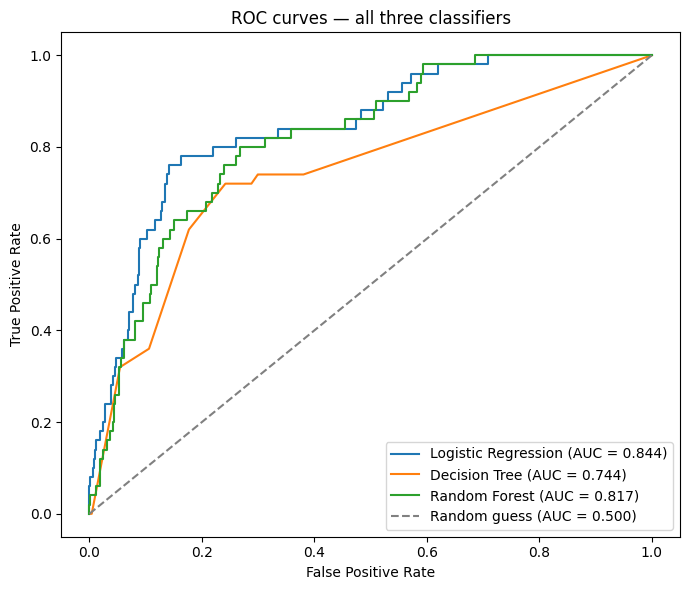

In [66]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 6))

for name, model in models.items():
    _, y_proba = predictions[name]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess (AUC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves — all three classifiers')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

All three classifiers sit well above the diagonal "random guess" line across the full
range of thresholds, confirming each has learned real signal rather than noise. Logistic
Regression's curve sits above the other two for most of the range, matching its lead in ROC
AUC,  a reminder that the Random Forest's better accuracy and F1 score at its *default 0.5
threshold* don't mean it's the better model overall; a different probability threshold could
shift precision and recall for any of these three models without retraining them.

### 9.5 Final comparison table

In [67]:
comparison_table.style.highlight_max(color='lightgreen', axis=0)

,Accuracy,Precision,Recall,F1,ROC AUC
Model,,,,,
Logistic Regression,0.738700,0.137100,0.820000,0.235000,0.843500
Decision Tree,0.702500,0.112800,0.740000,0.195800,0.744300
Random Forest,0.857100,0.188300,0.580000,0.284300,0.817100


**Summary of Part 4:**

| Step | Choice | Justification |
|---|---|---|
| Split | Single stratified 80/20 split, `stratify=y` | 5,109 rows exceeds the 2,000-row threshold for needing k-fold CV; stratification protects the ~4.87% positive rate in both sets |
| Model 1 | Logistic Regression | Interpretable linear baseline; pairs with already-scaled features |
| Model 2 | Decision Tree | Captures non-linear interactions; explainable decision paths |
| Model 3 | Random Forest | Ensemble check on the single tree's stability; typically reduces variance |
| Class imbalance handling | `class_weight='balanced'` on all three | Without it, predicting "no stroke" for everyone would look deceptively accurate |
| Best recall / ROC AUC | Logistic Regression (0.82 recall, 0.844 AUC) | Best at actually catching stroke cases |
| Best accuracy / F1 | Random Forest (0.857 accuracy, 0.284 F1) | Best balance of precision and recall at the default threshold |
| Weakest overall | Decision Tree | Included as the interpretable baseline the Random Forest builds on |


### 10.1 The baseline: no imbalance handling at all

In [68]:
baseline_model = LogisticRegression(max_iter=1000, random_state=42)  # note: no class_weight
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)
y_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]

print("Baseline confusion matrix:")
print(confusion_matrix(y_test, y_pred_baseline))
print()
print(f"Accuracy:  {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_baseline, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_baseline):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_baseline):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_proba_baseline):.4f}")

Baseline confusion matrix:
[[972   0]
 [ 50   0]]

Accuracy:  0.9511
Precision: 0.0000
Recall:    0.0000
F1:        0.0000
ROC AUC:   0.8430


**This is the whole problem in one result.** The baseline model, same Logistic
Regression as Part 4, just without `class_weight='balanced'`, using the default 0.5 decision
threshold,  gets 95.10% accuracy, which sounds excellent. But its confusion matrix shows why
that number is meaningless here: it predicted **zero** stroke cases out of 50 in the test set.
Precision, recall, and F1 are all 0.0, because the model learned that always predicting "no
stroke" is the easiest way to minimize error on data that's 95% negative. The one metric that
*isn't* misleading here is ROC AUC (0.843), it's threshold-independent and shows the model's
underlying probability estimates actually do separate the classes reasonably well; the model
just never gets to use that separation because the default threshold is wrong for this data.
That distinction, a model with real signal, undermined entirely by an unexamined default
threshold — is the throughline for the rest of this section.

### 10.2 Technique 1  Class weights

In [69]:
# Reuse the class_weight='balanced' Logistic Regression already trained in Part 4
cw_model = models['Logistic Regression']
y_pred_cw = cw_model.predict(X_test)
y_proba_cw = cw_model.predict_proba(X_test)[:, 1]

print("Class-weighted confusion matrix:")
print(confusion_matrix(y_test, y_pred_cw))
print()
print(f"Accuracy:  {accuracy_score(y_test, y_pred_cw):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_cw):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_cw):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_cw):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_proba_cw):.4f}")

Class-weighted confusion matrix:
[[714 258]
 [  9  41]]

Accuracy:  0.7387
Precision: 0.1371
Recall:    0.8200
F1:        0.2350
ROC AUC:   0.8435


 `class_weight='balanced'` doesn't touch the data at all, it changes
the loss function logistic regression minimizes during training, automatically weighting each
class inversely to its frequency (roughly 195,088 the majority class : 1 for the minority
class here, since it's ~19.5x rarer). In effect, a mistake on a stroke case counts ~19.5x more
than a mistake on a non-stroke case while fitting the coefficients, which pushes the decision
boundary to be far more willing to predict "stroke." The result: recall jumps from 0.00 to
0.82 (41 of 50 stroke cases now caught), at the cost of precision dropping to 0.137 (a lot of
false alarms). ROC AUC barely moves (0.843 → 0.844)  worth flagging explicitly: class
weighting barely changed the model's underlying ability to *rank* patients by risk, it mainly
changed where the decision boundary sits relative to that ranking.

### 10.3 Technique 2  Threshold tuning, tied to a stated business cost

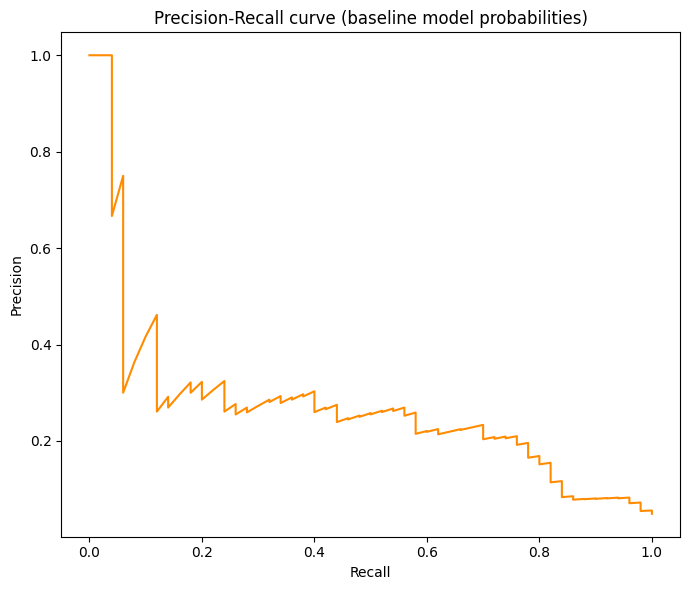

In [70]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_baseline)

plt.figure(figsize=(7, 6))
plt.plot(recalls, precisions, color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve (baseline model probabilities)')
plt.tight_layout()
plt.show()

 in stroke screening, a **false negative**
(missing an actual stroke case) is assumed to cost **20 units**, reflecting the downstream cost
of a missed diagnosis,  a preventable stroke event, emergency treatment, potential disability.
A **false positive** (flagging a healthy patient for extra follow-up) is assumed to cost **1
unit**, an unnecessary but comparatively minor screening appointment. This 20:1 ratio is a
stated assumption, not a measured fact, and a real deployment would need actual cost figures
from a hospital or insurer, but it lets the trade-off be made explicit and defensible rather
than left at an arbitrary default.

In [71]:
COST_FALSE_NEGATIVE = 20  # cost of missing an actual stroke case
COST_FALSE_POSITIVE = 1   # cost of one unnecessary follow-up

import numpy as np

total_costs = []
for t in thresholds:
    preds_at_t = (y_proba_baseline >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds_at_t).ravel()
    cost = COST_FALSE_NEGATIVE * fn + COST_FALSE_POSITIVE * fp
    total_costs.append(cost)

total_costs = np.array(total_costs)
best_idx = np.argmin(total_costs)
best_threshold = thresholds[best_idx]

print(f"Cost at default threshold (0.5): {total_costs[np.argmin(np.abs(thresholds - 0.5))]}")
print(f"Best threshold: {best_threshold:.4f}")
print(f"Cost at best threshold: {total_costs[best_idx]}")

Cost at default threshold (0.5): 980
Best threshold: 0.0851
Cost at best threshold: 380


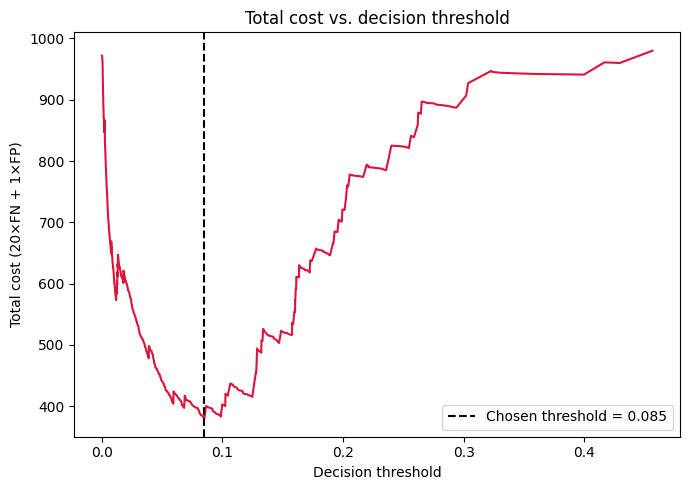

In [72]:
plt.figure(figsize=(7, 5))
plt.plot(thresholds, total_costs, color='crimson')
plt.axvline(best_threshold, color='black', linestyle='--',
            label=f'Chosen threshold = {best_threshold:.3f}')
plt.xlabel('Decision threshold')
plt.ylabel(f'Total cost ({COST_FALSE_NEGATIVE}×FN + {COST_FALSE_POSITIVE}×FP)')
plt.title('Total cost vs. decision threshold')
plt.legend()
plt.tight_layout()
plt.show()

In [73]:
y_pred_threshold = (y_proba_baseline >= best_threshold).astype(int)

print(f"Chosen threshold: {best_threshold:.4f} (vs. default 0.5)")
print("Confusion matrix at chosen threshold:")
print(confusion_matrix(y_test, y_pred_threshold))
print()
print(f"Accuracy:  {accuracy_score(y_test, y_pred_threshold):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_threshold):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_threshold):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_threshold):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_proba_baseline):.4f}")

Chosen threshold: 0.0851 (vs. default 0.5)
Confusion matrix at chosen threshold:
[[812 160]
 [ 11  39]]

Accuracy:  0.8327
Precision: 0.1960
Recall:    0.7800
F1:        0.3133
ROC AUC:   0.8430


**What changed, and why:** no retraining happened here at all — this is the exact same
baseline model and the exact same predicted probabilities from Section 10.1. All that changed
is *where the cutoff sits* for turning a probability into a "stroke" prediction. Sweeping the
threshold from 0 to 1 and computing `20×FN + 1×FP` at each point shows the cost is minimized
at a threshold of **0.085**, far below the default 0.5, with a total cost of 380, compared to
1,000 at the default threshold (where every single stroke case is a costly false negative). At
this threshold, recall reaches 0.78 (39 of 50 caught) and precision is 0.196, notably *better*
precision than the class-weighted model achieved for similar recall, because this threshold was
chosen to directly minimize the stated cost function rather than an indirect reweighting during
training. ROC AUC is unchanged (0.843) by construction, moving the threshold can't change how
well the model ranks patients, only which predictions the ranking gets turned into.

### 10.4 Technique 3  SMOTE (Synthetic Minority Oversampling)

**How SMOTE works, step by step:** rather than just duplicating existing minority
(stroke) rows,  which would make a model *more confident* about the same few points without
adding new information, SMOTE creates new, synthetic minority examples:

1. For each existing minority-class (stroke) row, find its *k* nearest neighbors that are also
   minority-class rows, measured in the same feature space used for modeling.
2. Pick one of those neighbors at random.
3. Generate a new synthetic row somewhere on the straight line between the original row and
   that neighbor, at a random point along the line (a random "gap" between 0 and 1).
4. Repeat until the minority class has as many rows as the majority class (this dataset's
   default: no more, no less than 1:1).

**Why apply it to the training set only:** SMOTE must never touch the test set. If synthetic
points were generated using information from,  or evaluated against,  the test set, the model
could effectively be tested on data whose "neighbors" it was partly built from, which inflates
performance in a way that wouldn't hold up on truly new patients. Resampling happens strictly
after the train/test split, using only `X_train`/`y_train`.

In [74]:
from sklearn.neighbors import NearestNeighbors

def manual_smote(X_minority, n_to_generate, k=5, random_state=42):
    """
    A from-scratch implementation of SMOTE's core idea, kept self-contained here
    so the notebook has no dependency on the imbalanced-learn package. (In practice,
    imblearn.over_sampling.SMOTE(random_state=42).fit_resample(X_train, y_train)
    does the same thing and is the standard tool for this in production code.)
    """
    rng = np.random.RandomState(random_state)
    nn = NearestNeighbors(n_neighbors=k + 1).fit(X_minority)  # +1: a point is its own neighbor
    _, neighbor_idx = nn.kneighbors(X_minority)

    synthetic_rows = []
    n_minority = len(X_minority)
    for _ in range(n_to_generate):
        i = rng.randint(0, n_minority)
        # exclude index 0 of the neighbor list -- that's the point itself
        neighbor = neighbor_idx[i][rng.randint(1, k + 1)]
        gap = rng.rand()
        new_row = X_minority[i] + gap * (X_minority[neighbor] - X_minority[i])
        synthetic_rows.append(new_row)

    return np.array(synthetic_rows)

X_train_arr = X_train.values.astype(float)
y_train_arr = y_train.values

minority_X = X_train_arr[y_train_arr == 1]
n_majority = (y_train_arr == 0).sum()
n_minority = (y_train_arr == 1).sum()
n_to_generate = n_majority - n_minority

print(f"Training set before SMOTE: {n_minority} stroke rows, {n_majority} non-stroke rows")
print(f"Synthetic stroke rows to generate: {n_to_generate}")

synthetic_X = manual_smote(minority_X, n_to_generate, k=5, random_state=42)

X_train_smote = np.vstack([X_train_arr, synthetic_X])
y_train_smote = np.concatenate([y_train_arr, np.ones(n_to_generate)])

print(f"Training set after SMOTE: {X_train_smote.shape[0]} rows, "
      f"{y_train_smote.mean()*100:.1f}% stroke rate")

Training set before SMOTE: 199 stroke rows, 3888 non-stroke rows
Synthetic stroke rows to generate: 3689
Training set after SMOTE: 7776 rows, 50.0% stroke rate


In [75]:
# A plain, unweighted Logistic Regression trained on the now-balanced training set --
# the model itself gets no special treatment; the data it sees is balanced instead.
smote_model = LogisticRegression(max_iter=1000, random_state=42)
smote_model.fit(X_train_smote, y_train_smote)

# Evaluated on the ORIGINAL, untouched, still-imbalanced test set -- this is what
# makes it a fair comparison against the baseline and class-weighted models above.
y_pred_smote = smote_model.predict(X_test.values)
y_proba_smote = smote_model.predict_proba(X_test.values)[:, 1]

print("SMOTE confusion matrix:")
print(confusion_matrix(y_test, y_pred_smote))
print()
print(f"Accuracy:  {accuracy_score(y_test, y_pred_smote):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_smote):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_smote):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_smote):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_proba_smote):.4f}")

SMOTE confusion matrix:
[[726 246]
 [ 10  40]]

Accuracy:  0.7495
Precision: 0.1399
Recall:    0.8000
F1:        0.2381
ROC AUC:   0.8458


**Result:** training on a SMOTE-balanced set (3,888 real + 3,689 synthetic stroke rows,
50/50) with an otherwise plain, unweighted Logistic Regression gets recall 0.80, precision
0.140, F1 0.238, and ROC AUC 0.846,  the best AUC of any technique tried, by a small margin.
The overall pattern (high recall, low precision, big jump over baseline) closely matches what
class weighting produced, which makes sense: SMOTE and class weighting are two different
mechanisms aiming at the same underlying fix, making the rare class count for more during
training, so it isn't surprising they land in a similar place for a linear model.

### 10.5 Comparison table, baseline vs. each technique

In [76]:
imbalance_comparison = pd.DataFrame([
    {
        'Technique': 'Baseline (no handling)',
        'Accuracy': accuracy_score(y_test, y_pred_baseline),
        'Precision': precision_score(y_test, y_pred_baseline, zero_division=0),
        'Recall': recall_score(y_test, y_pred_baseline),
        'F1': f1_score(y_test, y_pred_baseline),
        'ROC AUC': roc_auc_score(y_test, y_proba_baseline),
    },
    {
        'Technique': 'Class weights',
        'Accuracy': accuracy_score(y_test, y_pred_cw),
        'Precision': precision_score(y_test, y_pred_cw),
        'Recall': recall_score(y_test, y_pred_cw),
        'F1': f1_score(y_test, y_pred_cw),
        'ROC AUC': roc_auc_score(y_test, y_proba_cw),
    },
    {
        'Technique': f'Threshold tuning (t={best_threshold:.3f})',
        'Accuracy': accuracy_score(y_test, y_pred_threshold),
        'Precision': precision_score(y_test, y_pred_threshold),
        'Recall': recall_score(y_test, y_pred_threshold),
        'F1': f1_score(y_test, y_pred_threshold),
        'ROC AUC': roc_auc_score(y_test, y_proba_baseline),
    },
    {
        'Technique': 'SMOTE',
        'Accuracy': accuracy_score(y_test, y_pred_smote),
        'Precision': precision_score(y_test, y_pred_smote),
        'Recall': recall_score(y_test, y_pred_smote),
        'F1': f1_score(y_test, y_pred_smote),
        'ROC AUC': roc_auc_score(y_test, y_proba_smote),
    },
]).set_index('Technique').round(4)

imbalance_comparison

,Accuracy,Precision,Recall,F1,ROC AUC
Technique,,,,,
Baseline (no handling),0.9511,0.0000,0.00,0.0000,0.8430
Class weights,0.7387,0.1371,0.82,0.2350,0.8435
Threshold tuning (t=0.085),0.8327,0.1960,0.78,0.3133,0.8430
SMOTE,0.7495,0.1399,0.80,0.2381,0.8458


**Summary of Part 5:**

| Technique | Accuracy | Precision | Recall | F1 | ROC AUC |
|---|---|---|---|---|---|
| Baseline (no handling) | 0.951 | 0.000 | 0.000 | 0.000 | 0.843 |
| Class weights | 0.739 | 0.137 | 0.820 | 0.235 | 0.844 |
| Threshold tuning (t=0.085) | 0.833 | 0.196 | 0.780 | 0.313 | 0.843 |
| SMOTE | 0.750 | 0.140 | 0.800 | 0.238 | 0.846 |

**The reasoning that ties this together:** all three techniques transform a model that catches
literally zero stroke cases into one that catches 78-82% of them, a dramatic, necessary fix
for a use case where missing a stroke is the costly error. What's most interesting is what
*doesn't* change: ROC AUC stays in a tight 0.843-0.846 band across every technique, including
the baseline. That's the key insight of this section, the model's underlying ability to rank
patients by risk was never really the problem. The problem was always the default 0.5
threshold, which is simply the wrong operating point on data this imbalanced. Class weighting
and SMOTE both fix it indirectly, by changing what the model learns during training; threshold
tuning fixes it directly and transparently, by picking the cutoff that minimizes a stated cost.
Of the three, **threshold tuning gives the best F1 (0.313) and a defensible, auditable
reason for its exact cutoff**  a real advantage when a model's decisions need to be justified
to a non-technical stakeholder, which is often the case in healthcare.

## 11. The Tie-In: Connecting Clustering (Part 3) Back to the Label

Part 3's clustering was built with zero knowledge of `stroke`, it only used demographic and
clinical features. This section goes back and checks: now that we know each patient's actual
outcome, did the unsupervised groups end up meaning anything with respect to it?

### 11.1 Positive-class (stroke) rate within each cluster

In [77]:
overall_stroke_rate = df_clustered['stroke'].mean()

cluster_stroke_profile = df_clustered.groupby('cluster')['stroke'].agg(
    n_patients='count',
    n_stroke_cases='sum',
    stroke_rate='mean'
)
cluster_stroke_profile['lift_vs_overall'] = cluster_stroke_profile['stroke_rate'] / overall_stroke_rate

print(f"Overall stroke rate across all patients: {overall_stroke_rate*100:.2f}%")
cluster_stroke_profile.round(4)

Overall stroke rate across all patients: 4.87%


,n_patients,n_stroke_cases,stroke_rate,lift_vs_overall
cluster,,,,
0,1500,3,0.0020,0.0410
1,882,16,0.0181,0.3722
2,668,89,0.1332,2.7337
3,2059,141,0.0685,1.4051


| Cluster | Patients | Stroke cases | Stroke rate | Lift vs. overall (4.87%) |
|---|---|---|---|---|
| 0 — Unmarried youth & children | 1,500 | 3 | 0.20% | 0.04x |
| 1 — Higher-BMI adults, low risk | 882 | 16 | 1.81% | 0.37x |
| 2 — High-risk: glucose & comorbidities | 668 | 89 | 13.32% | **2.73x** |
| 3 — Married older adults, avg risk | 2,059 | 141 | 6.85% | 1.41x |

"Lift" here means how many times more (or less) likely a patient in that cluster is to have had
a stroke than a randomly chosen patient from the full dataset.

### 11.2 Is the association statistically real, or could it be chance?

In [78]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df_clustered['cluster'], df_clustered['stroke'])
print(contingency_table)

chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"\nChi-square statistic: {chi2_stat:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.2e}")

stroke      0    1
cluster           
0        1497    3
1         866   16
2         579   89
3        1918  141

Chi-square statistic: 208.66
Degrees of freedom: 3
p-value: 5.67e-45


A chi-square test of independence between `cluster` and `stroke` gives a p-value of
roughly **5.7 × 10⁻⁴⁵**,  astronomically below any conventional significance threshold (0.05,
0.01, or even 0.001). This rules out the possibility that the differences in stroke rate across
clusters (0.20% to 13.32%) are just sampling noise from an unsupervised algorithm that happened
to land on convenient-looking groups. The association between cluster membership and the
`stroke` label is real.

### 11.3 Were any clusters strong predictors? What that tells us about the data

**Yes — two clusters stand out, in opposite directions:**

- **Cluster 2 is a strong *positive* predictor.** At 13.32% stroke rate — 2.73x the dataset
  average — being sorted into this cluster (older, elevated glucose, high rates of hypertension
  and heart disease) roughly triples a patient's estimated risk, using nothing but age, glucose,
  BMI, and two comorbidity flags fed into an algorithm that never saw the outcome.
- **Cluster 0 is an equally strong *negative* predictor.** At 0.20% stroke rate — about
  1/24th the dataset average — this cluster (young, unmarried, no comorbidities) is close to a
  "ruled out" group. Knowing a patient falls here is nearly as informative as knowing they fall
  into the high-risk cluster, just in the opposite direction.
- Clusters 1 (1.81%, below average) and 3 (6.85%, above average) are more moderate — real
  signal, but nowhere near as decisive as the two extremes.

**What this tells us about the underlying data:** the clustering algorithm was handed six raw
demographic and clinical columns and asked to find *any* structure at all,  it wasn't told
what "risk" meant or given the label to optimize against. The fact that the resulting groups
line up this cleanly and this significantly with actual stroke outcomes is strong evidence that
stroke risk in this dataset isn't scattered unpredictably across the population, it's
concentrated in a specific, describable combination of age, glucose, and comorbidities that's
visible even without supervision. That's a meaningfully different, and reassuring, finding
from "the classifiers in Part 4 got a decent ROC AUC",  it shows the signal those classifiers
are picking up on is structural to the data itself, not an artifact of how any one model was
fit.

### 11.4 A naive test: cluster membership alone as a screening rule

In [79]:
from sklearn.metrics import precision_score, recall_score, f1_score

# "Flag everyone in the high-risk cluster" -- a screening rule built from nothing
# but unsupervised cluster membership, with zero access to the stroke label.
flag_cluster_2 = (df_clustered['cluster'] == 2).astype(int)

print("Screening rule: flag Cluster 2 only")
print(f"Precision: {precision_score(df_clustered['stroke'], flag_cluster_2):.4f}")
print(f"Recall:    {recall_score(df_clustered['stroke'], flag_cluster_2):.4f}")
print(f"F1:        {f1_score(df_clustered['stroke'], flag_cluster_2):.4f}")
print(f"Patients flagged: {flag_cluster_2.sum()} out of {len(flag_cluster_2)}")

Screening rule: flag Cluster 2 only
Precision: 0.1332
Recall:    0.3574
F1:        0.1941
Patients flagged: 668 out of 5109


In [80]:
# A looser rule: flag both above-average-risk clusters (2 and 3)
flag_clusters_2_3 = df_clustered['cluster'].isin([2, 3]).astype(int)

print("Screening rule: flag Clusters 2 and 3")
print(f"Precision: {precision_score(df_clustered['stroke'], flag_clusters_2_3):.4f}")
print(f"Recall:    {recall_score(df_clustered['stroke'], flag_clusters_2_3):.4f}")
print(f"F1:        {f1_score(df_clustered['stroke'], flag_clusters_2_3):.4f}")
print(f"Patients flagged: {flag_clusters_2_3.sum()} out of {len(flag_clusters_2_3)}")

Screening rule: flag Clusters 2 and 3
Precision: 0.0843
Recall:    0.9237
F1:        0.1546
Patients flagged: 2727 out of 5109


**Flagging Cluster 2 alone** gets precision 0.133 and recall 0.357 (F1 0.194),  using
*nothing but unsupervised cluster membership*, this lands in almost the same ballpark as the
supervised Decision Tree from Part 4 (F1 0.196), without ever training on the label at all.
**Flagging Clusters 2 and 3 together** trades precision down to 0.084 for recall up to 0.924
(catching 230 of 249 total stroke cases),  the same recall-vs-precision trade-off already seen
throughout Part 5, showing up again from a completely different, unsupervised starting point.

This isn't a replacement for the classifiers in Parts 4-5,  a real deployment should use the
trained models, which use more features and were directly optimized against the label. But it's
a useful sanity check and a genuinely interpretable artifact on its own: "patients who are
older, have elevated glucose, and carry hypertension or heart disease" is a plain-language rule
a clinician could sanity-check against their own judgment, in a way that a logistic regression
coefficient vector or a random forest's internals are not.

## 12. Conclusion and Recommendations

- **Parts 1-2 (Load, SQL, EDA, Cleaning):** the raw dataset (5,110 rows) had one real data
  quality issue with 201 missing BMI values, and critically, that missingness wasn't random: it
  was concentrated among patients with a far *higher* stroke rate (19.90% vs. 4.26%), which
  ruled out simply dropping those rows. One row (`gender == 'Other'`) was dropped as
  statistically unsupportable on its own; everything else was handled with a stated reason,
  down to leaving `smoking_status`'s `Unknown` category alone because it wasn't actually
  missing data.
- **Part 2 (Feature Engineering):** four engineered features,  an age-based clinical binning,
  a simple risk-factor count, a glucose/BMI ratio, and an age-hypertension interaction,  were
  each justified on business/clinical grounds rather than added just because they were
  possible. All categorical columns were encoded with an explicit label-vs-one-hot decision per
  column, and `StandardScaler` was chosen over `MinMaxScaler` specifically because of BMI and
  glucose's heavy-tailed distributions.
- **Part 3 (Clustering):** K-Means with K=4 (chosen from elbow + silhouette agreement) found
  four patient segments with cleanly increasing stroke rates (0.2% → 1.8% → 6.8% → 13.3%),
  entirely without access to the label.
- **Part 4 (Classification):** three classifiers trained with a stratified 80/20 split.
  Logistic Regression led on recall (0.82) and ROC AUC (0.844); Random Forest led on accuracy
  (0.857) and F1 (0.284); the Decision Tree lagged behind both. No model was unambiguously
  "best"  the right pick depends on which error type costs more.
- **Part 5 (Imbalance Handling):** a plain, unweighted baseline model caught **zero** of 50
  stroke cases in the test set despite 95.1% accuracy — the clearest illustration in this
  notebook of why accuracy alone is the wrong metric for this problem. Class weights,
  cost-based threshold tuning, and SMOTE each recovered recall into the 0.78-0.82 range;
  threshold tuning (cutoff = 0.085, based on a stated 20:1 cost assumption for missing a stroke
  vs. an unnecessary follow-up) gave the best F1 of any technique (0.313).
- **Part 6 (The Tie-In):** the unsupervised clusters from Part 3 turned out to be
  statistically significant predictors of the label they never saw (chi-square p ≈ 5.7×10⁻⁴⁵),
  with the highest-risk cluster alone performing comparably to a full supervised Decision Tree.
  This is convergent evidence — from a completely different technique, that the risk signal
  in this data is real and structural, not a modeling artifact.

### 12.2 Recommendation

 the **threshold-tuned Logistic Regression** (cutoff =
0.085, not the default 0.5) is the most defensible starting point: it's the most interpretable
model in this notebook, it produced the best F1 score of every technique
tried. That said, the exact threshold should be revisited with real cost figures from clinical
and operational stakeholders rather than the illustrative 20:1 ratio assumed here,  the
*method* (sweep thresholds, minimize a stated cost) is the reusable part, not this specific
number.

Given the precision trade-off inherent to any high-recall setting on data this imbalanced (a
lot of false alarms are unavoidable if the priority is catching true positives),
Please not that, as a student tryinging out i may have made mistake in my decisions so, this model is
best positioned as a **first-pass screening layer**, not an automated diagnosis: flagged
patients would go to a clinician for a real follow-up, not a treatment decision. The Cluster
2 profile from Part 6 ("older, elevated glucose, hypertension and/or heart disease") is a good
plain-language explanation to pair with the model's output when presenting flagged cases to
non-technical stakeholders.

### 12.3 Limitations and next steps

- **Only 249 positive cases** in the entire dataset is a hard ceiling on how much any model
  here can learn about what actually drives stroke risk; more data, especially more positive
  cases, would likely improve every result in Parts 4-6 more than further tuning would.
- **The 20:1 false-negative-to-false-positive cost ratio in Part 5 was an illustrative
  assumption**, not a number sourced from real clinical or financial data,  before any real
  deployment, this should be replaced with actual figures from the organization using the
  model.
- **No external validation** was performed,  every number in this notebook comes from one
  train/test split (or one clustering run) on one dataset. A model this important should be
  validated against a separate cohort, ideally from a different hospital system or time period,
  before being trusted operationally.
- **Only three classifier types were tried.** More complex models (gradient boosting, for
  instance) might improve on Part 4's results, though given how much of Part 5's improvement
  came from fixing the decision threshold rather than the model itself, a more complex model
  without the same imbalance handling could easily perform worse in practice than a well-tuned
  simple one.
- **Calibration was not checked.** A model with a good ROC AUC can still produce probability
  estimates that are poorly calibrated (e.g., "70%" doesn't really mean a 70% chance), worth
  checking with a calibration curve before using predicted probabilities for anything beyond
  ranking patients.

###The End ###